# RL agent sims (260715): model characterisation by centrality strategy

~40 social (2-agent) self-play models trained in `Octagon/results/2607/260715`. Per `notes_260715.txt` these are **seed-replicate models**: identical config to the 0.01-RND / no-penalty-break agents of 260624, but with a **random seed per run** instead of a fixed trial sequence. The only deliberate parameter change within the set is training length — **from model 25 the total training steps was cut from 4e6 to 3e6**.

Because the models share parameters and differ mainly by seed, the quantity of interest is the **between-model variability**. The goal is to split it into a *gross strategy* axis and *intra-strategy variability*, then pick a spread of models for a tournament.

**The characterisation axis is centrality at slice onset.** For each trial, at the frame the walls appear, centrality `= 1 - r/R` (1 = arena centre, 0 = at a wall). A model's mean over trials is roughly where it stands when the trial starts, and defines a broadly central or broadly peripheral waiting strategy.

**Plan**
1. **Gross strategy** — per-model slice-onset centrality, split into central vs peripheral.
2. **Intra-strategy variability** — how the other behavioural metrics vary within each strategy, and which metrics separate the strategies vs vary freely inside them.
3. A shortlist of models for the tournament.

**Choices** (matching prior sim notebooks): FoV = 110.0; both agents pooled (self-play); everything that computes a number comes from `analysis/model_characterisation.py`, which loads through `parse_data.prepare_sim_data` and takes slice-onset position from `get_indices.get_player_slice_onset_loc`.

**Note on metrics.** The fingerprint metric for complete rest means no translational or rotational movement. Technically, this is a proxy, as it is calculated from positional information and not the actual decisions of the agents themselves. Therefore, if an agent is e.g. running into a wall, it will be taking action but considered resting. I have checked this across the 260715 models, and found that the difference between these two metrics is tiny. So, I am ignoring it for now as using position is much more convenient

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import data_strings
import analysis.model_characterisation as mc
import plotting.plot_octagon as plot_octagon

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

# social self-play inference logs for this run live in a dated subfolder
SIM_DATA_FOLDER = os.path.join(data_strings.SIM_DATA_FOLDER, '2607', '260715')

CURRENT_FOV = 110.0                 # agent camera FoV (total degrees)

In [2]:
# the only deliberate parameter difference within the set is training length
# notes_260715.txt: "From model 25, total training steps was reduced from 4e06 to 3e06".
TRAIN_STEP_CUTOFF = 25
def train_steps(model):
    return '3e6' if model >= TRAIN_STEP_CUTOFF else '4e6'

TRAIN_PALETTE = {'4e6': '#4C72B0', '3e6': '#DD8452'}

# discover whatever models are present (seed replicates, no a-priori strategy groups)
ALL_MODELS = mc.get_batch_models(SIM_DATA_FOLDER)
print(f"models found: {len(ALL_MODELS)}")
print(ALL_MODELS)
print(f"4e6-step models (< {TRAIN_STEP_CUTOFF}): {[m for m in ALL_MODELS if m < TRAIN_STEP_CUTOFF]}")
print(f"3e6-step models (>= {TRAIN_STEP_CUTOFF}): {[m for m in ALL_MODELS if m >= TRAIN_STEP_CUTOFF]}")

models found: 39
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
4e6-step models (< 25): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
3e6-step models (>= 25): [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


## Main pass over all models

One pass per model builds the long tables: `slice` (slice-onset centrality and x,z, one row per trial x agent), `iti`, `vis`, `score` and `rt`. Each model is loaded, measured, then discarded, so the batch stays memory-safe. Slice-onset x,z are kept so the occupancy heatmaps can be split by strategy after classification. Runs with no completed trials are skipped.

In [3]:
tables = mc.collect_model_data(SIM_DATA_FOLDER, models=ALL_MODELS, fov=CURRENT_FOV)
USABLE_MODELS = mc.summarise_collection(tables, ALL_MODELS)
slice_df, iti_df = tables['slice'], tables['iti']

model  1 done  

model  2 done  

model  3 done  

model  4 done  

model  5 done  

...

model 35 done  

model 36 done  

model 37 done  

model 38 done  

model 39 done  

usable models: 37 / 39
skipped (no usable trials): [(18, 'TypeError'), (19, 'TypeError')]
slice-onset rows: 14694 | ITIs: 14768 | visibility rows: 12476 | scored trials: 7347
trials per model: min 194, max 199


## Stage 1 - the strategy axis (centrality at slice onset)

Each model's mean slice-onset centrality summarises its strategy. Models are ranked by it (bar = mean, whisker = SD across trials), with the spread of individual trials shown below. A tight spread means the model starts most trials from a similar distance out; a wide one means its start position varies a lot.

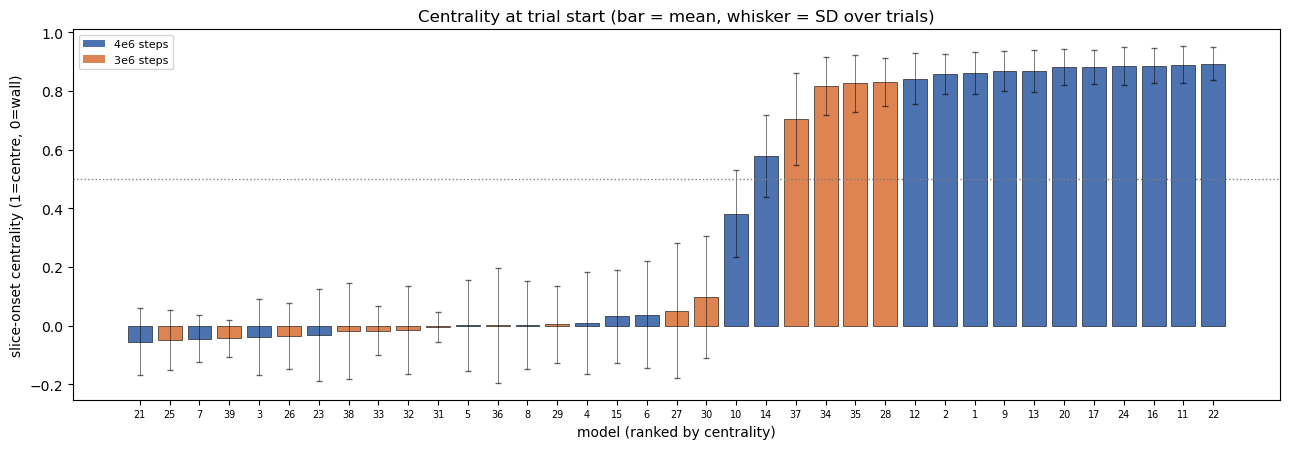

In [4]:
onset_by_model = mc.onset_centrality_by_model(slice_df)

order = onset_by_model.sort_values('onset_centrality').reset_index(drop=True)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.bar(x, order['onset_centrality'], yerr=order['onset_sd'], capsize=2,
       color=[TRAIN_PALETTE[train_steps(m)] for m in order['model']], edgecolor='black', linewidth=0.4,
       error_kw=dict(lw=0.6, alpha=0.6))
ax.legend(handles=[Patch(facecolor=TRAIN_PALETTE[t], label=f'{t} steps') for t in ['4e6', '3e6']], fontsize=8)

ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels(order['model'], fontsize=7)
ax.set_xlabel('model (ranked by centrality)'); ax.set_ylabel('slice-onset centrality (1=centre, 0=wall)')
ax.set_title('Centrality at trial start (bar = mean, whisker = SD over trials)')
plt.tight_layout(); plt.show()

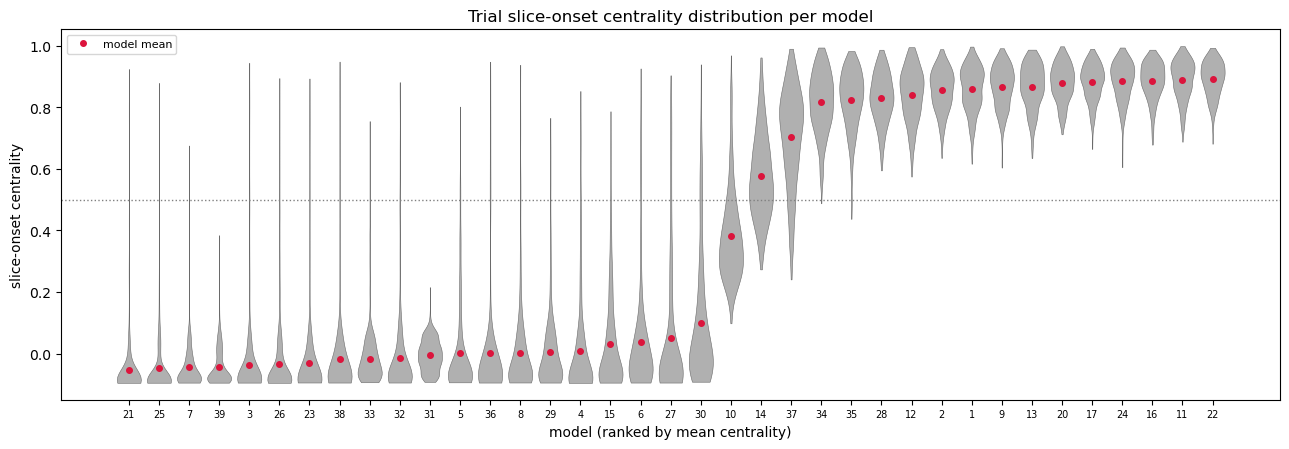

In [5]:
# plot the per-trial spread within each model, ordered by model mean
fig, ax = plt.subplots(figsize=(13, 4.6))
mean_order = onset_by_model.sort_values('onset_centrality')['model'].tolist()
sns.violinplot(data=slice_df, x='model', y='centrality', order=mean_order,
               density_norm='width', inner=None, cut=0, linewidth=0.4,
               color='#B0B0B0', ax=ax)
ax.plot(range(len(mean_order)),
        onset_by_model.set_index('model').loc[mean_order, 'onset_centrality'].values,
        'o', color='crimson', markersize=4, label='model mean')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xticks(range(len(mean_order)))
ax.set_xticklabels(mean_order, fontsize=7)
ax.set_xlabel('model (ranked by mean centrality)'); ax.set_ylabel('slice-onset centrality')
ax.set_title('Trial slice-onset centrality distribution per model')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Data-driven central vs peripheral split

Are "central" and "peripheral" two separate clusters, or just ends of one continuous range? The models are split two ways. (a) A fixed cut at centrality = 0.5, nearer the centre than a wall. (b) A 2-component Gaussian mixture fit to the per-model means, which finds its own boundary. If the two splits agree and the distribution has a clear gap, the split is real. If they disagree over a smooth spread, centrality is a sliding scale, not two groups.

GMM component means: [0.013 0.835]  weights: [0.57 0.43]
fixed(0.5) vs GMM agreement: 100%
strategy_gmm  strategy_fixed
central       central           16
peripheral    peripheral        21
Name: n, dtype: int64


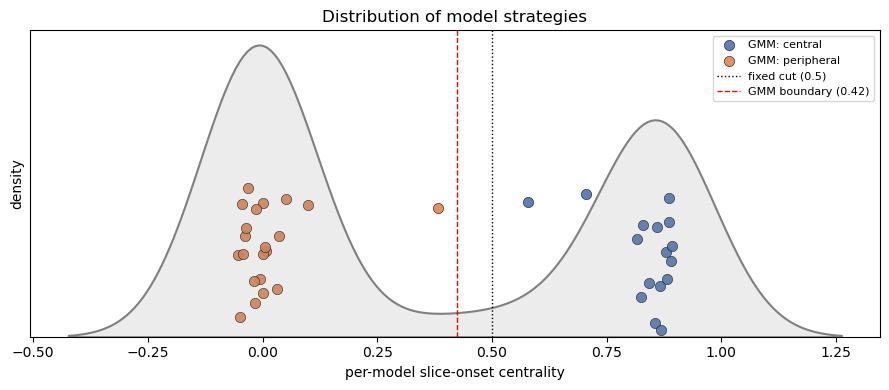

In [6]:
onset_by_model, gmm, boundary = mc.split_strategies(onset_by_model)
mc.report_strategy_split(onset_by_model, gmm)

vals = onset_by_model['onset_centrality'].to_numpy()
fig, ax = plt.subplots(figsize=(9, 4))
for lab, col in mc.STRAT_PALETTE.items():
    sub = onset_by_model[onset_by_model['strategy_gmm'] == lab]
    ax.scatter(sub['onset_centrality'], np.random.uniform(0, 1, len(sub)),
               color=col, edgecolor='black', linewidth=0.4, s=55, alpha=0.9, label=f'GMM: {lab}')
sns.kdeplot(x=vals, ax=ax, color='grey', lw=1.5, fill=True, alpha=0.15, bw_adjust=0.6)
ax.axvline(0.5, color='black', ls=':', lw=1, label='fixed cut (0.5)')
ax.axvline(boundary, color='red', ls='--', lw=1, label=f'GMM boundary ({boundary:.2f})')
ax.set_yticks([]); ax.set_xlabel('per-model slice-onset centrality'); ax.set_ylabel('density')
ax.set_title('Distribution of model strategies')
ax.legend(fontsize=8, loc='upper right'); plt.tight_layout(); plt.show()

In [7]:
# adopt the GMM label as the working strategy; both labels are carried for transparency
model_meta = mc.build_model_meta(USABLE_MODELS, onset_by_model, strategy_col='strategy_gmm')
model_meta['train_steps'] = model_meta['model'].map(train_steps)
mc.report_strategy_membership(model_meta)
print("\nStrategy x training-length:")
print(pd.crosstab(model_meta['strategy'], model_meta['train_steps']))

Strategy membership (working label = GMM):
  central     (n=16): [1, 2, 9, 11, 12, 13, 14, 16, 17, 20, 22, 24, 28, 34, 35, 37]
  peripheral  (n=21): [3, 4, 5, 6, 7, 8, 10, 15, 21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 36, 38, 39]

Strategy x training-length:
train_steps  3e6  4e6
strategy             
central        4   12
peripheral    11   10


## Stage 2 - intra-strategy variability

Collect a set of behavioural metrics per model. For each one, compare how much it differs **between** the two strategies against how much it differs **within** a strategy. Metrics that differ mostly between strategies are what central vs peripheral actually captures. Metrics that vary a lot within a strategy tell otherwise-similar models apart in some other way.

In [8]:
fingerprint = mc.build_fingerprint(model_meta, tables)
fingerprint[['model', 'strategy', 'train_steps'] + mc.FP_METRICS].round(3)

,model,strategy,train_steps,onset_centrality,iti_centrality,prop_no_translational,prop_no_rotational,proportion_resting,path_len,rot_total,frac_visible_at_onset,latency_s,frac_never_visible,frac_trials_over_5s,p_high,mean_score
0,1,central,4e6,0.861,0.810,0.255,0.365,0.092,36.671,1134.054,0.719,0.411,0.003,0.000,0.844,0.401
1,2,central,4e6,0.856,0.828,0.266,0.358,0.097,36.200,1149.696,0.658,0.306,0.000,0.000,0.854,0.497
2,3,peripheral,4e6,-0.038,-0.019,0.693,0.743,0.518,13.688,456.984,0.973,0.209,0.000,0.005,0.548,0.365
3,4,peripheral,4e6,0.008,0.029,0.776,0.859,0.670,9.728,250.434,0.925,1.108,0.014,0.010,0.558,0.336
4,5,peripheral,4e6,0.001,0.009,0.897,0.954,0.857,4.593,81.000,0.884,2.548,0.060,0.041,0.655,0.371
5,6,peripheral,4e6,0.037,0.047,0.761,0.882,0.676,10.853,208.314,0.914,1.143,0.010,0.010,0.714,0.416
6,7,peripheral,4e6,-0.045,-0.029,0.622,0.832,0.517,15.749,299.610,0.976,0.252,0.007,0.000,0.663,0.384
7,8,peripheral,4e6,0.002,0.020,0.489,0.687,0.337,22.846,556.632,0.931,0.572,0.010,0.000,0.648,0.408
8,9,central,4e6,0.867,0.839,0.211,0.383,0.085,38.860,1100.466,0.678,0.322,0.000,0.000,0.794,0.457
9,10,peripheral,4e6,0.382,0.325,0.761,0.824,0.628,11.771,312.092,0.742,3.197,0.093,0.067,0.784,0.473


In [9]:
var_table = mc.between_strategy_variance(fingerprint)
print("Between-strategy variance share (eta^2): 1 = fully explained by strategy, 0 = all within-strategy")
var_table.round(3)

Between-strategy variance share (eta^2): 1 = fully explained by strategy, 0 = all within-strategy


,metric,eta2_between_strategy,p_anova,central_mean,peripheral_mean
0,onset_centrality,0.957,0.000,0.835,0.013
1,iti_centrality,0.948,0.000,0.772,0.023
6,rot_total,0.904,0.000,1152.024,395.252
3,prop_no_rotational,0.904,0.000,0.355,0.778
5,path_len,0.782,0.000,35.874,16.045
4,proportion_resting,0.743,0.000,0.101,0.508
7,frac_visible_at_onset,0.739,0.000,0.683,0.884
2,prop_no_translational,0.710,0.000,0.272,0.636
11,p_high,0.565,0.000,0.854,0.695
10,frac_trials_over_5s,0.368,0.000,0.000,0.021


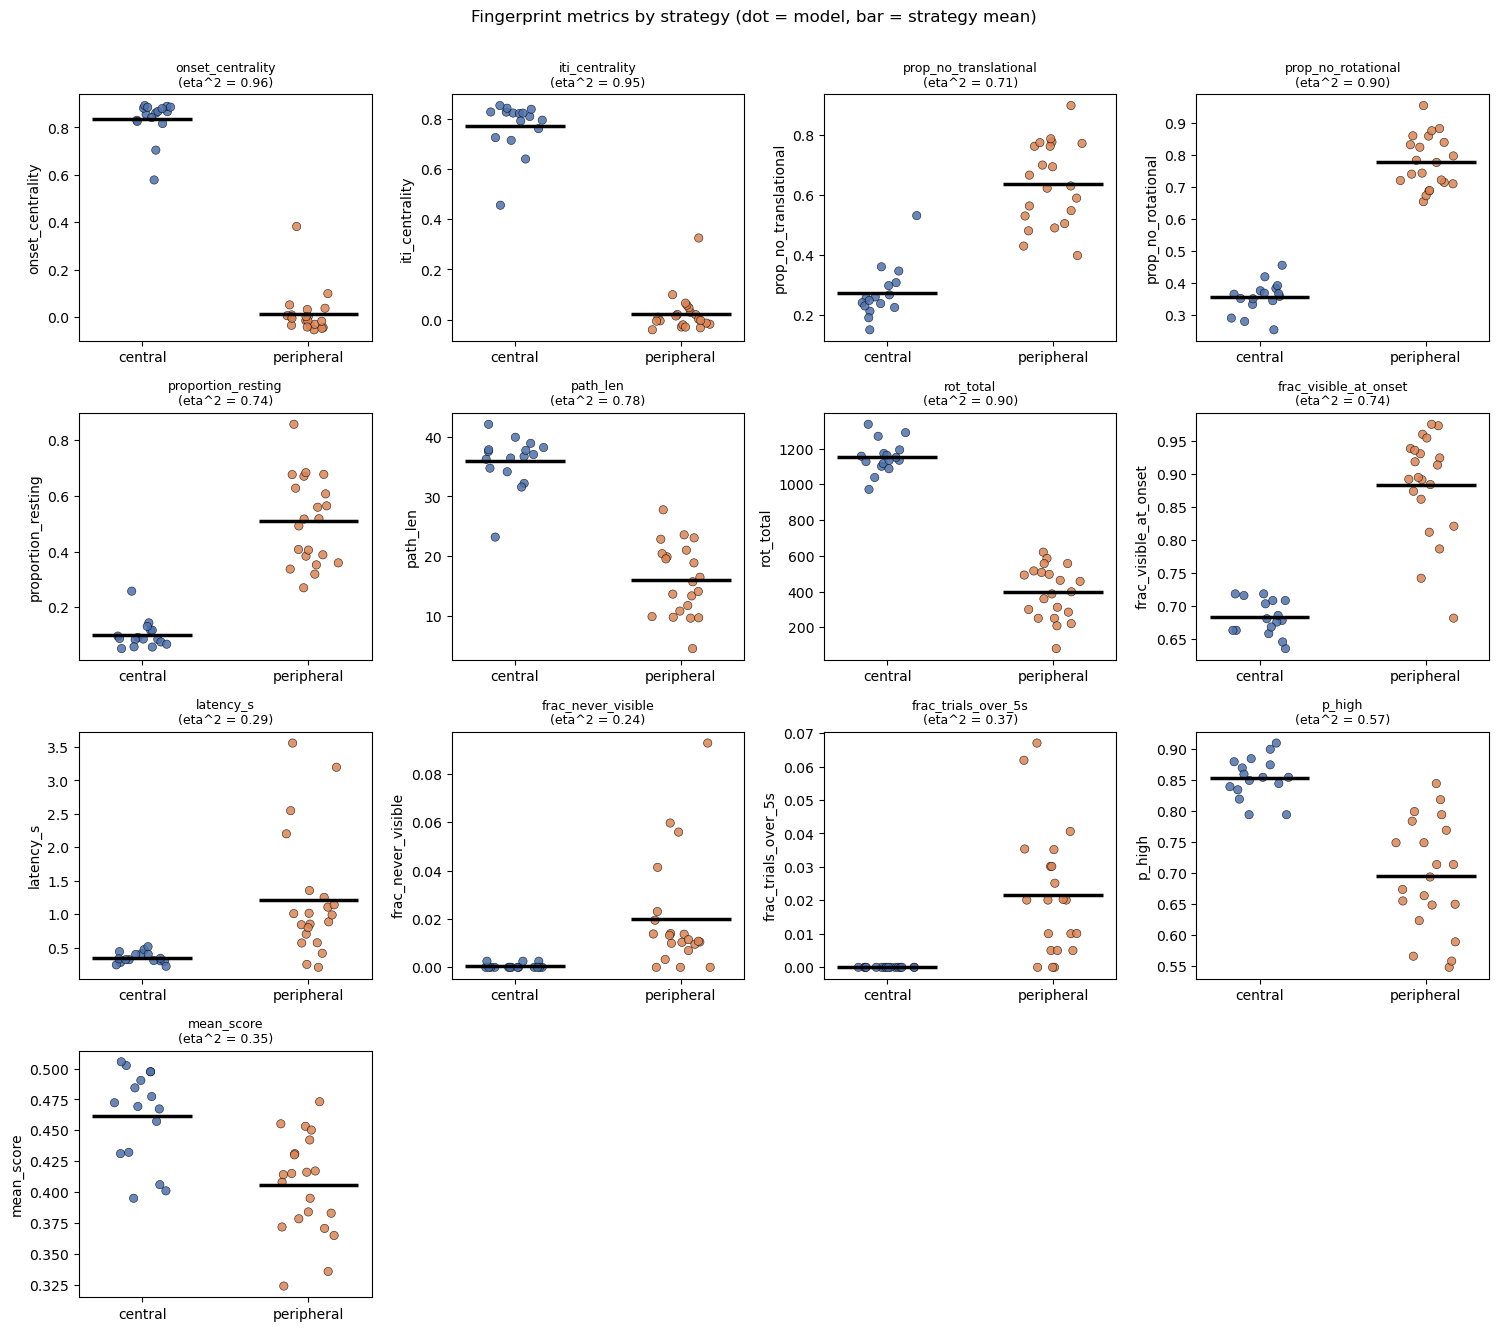

In [10]:
# plot central vs peripheral for each fingerprint metric (dot = model, bar = strategy mean)
ncol = 4
nrow = int(np.ceil(len(mc.FP_METRICS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.3 * nrow))
for ax, m in zip(axes.ravel(), mc.FP_METRICS):
    sns.stripplot(data=fingerprint, x='strategy', y=m, order=['central', 'peripheral'],
                  hue='strategy', palette=mc.STRAT_PALETTE, size=6, jitter=0.18,
                  alpha=0.85, edgecolor='black', linewidth=0.4, legend=False, ax=ax)
    means = fingerprint.groupby('strategy')[m].mean()
    for i, g in enumerate(['central', 'peripheral']):
        ax.hlines(means[g], i - 0.3, i + 0.3, color='black', lw=2.5, zorder=5)
    e = var_table.set_index('metric').loc[m, 'eta2_between_strategy']
    ax.set_title(f'{m}\n(eta^2 = {e:.2f})', fontsize=9); ax.set_xlabel('')
for ax in axes.ravel()[len(mc.FP_METRICS):]:
    ax.axis('off')
plt.suptitle('Fingerprint metrics by strategy (dot = model, bar = strategy mean)', y=1.005)
plt.tight_layout(); plt.show()

### Where each strategy stands at slice onset

Occupancy of the slice-onset position, split by strategy, with the octagon outline.

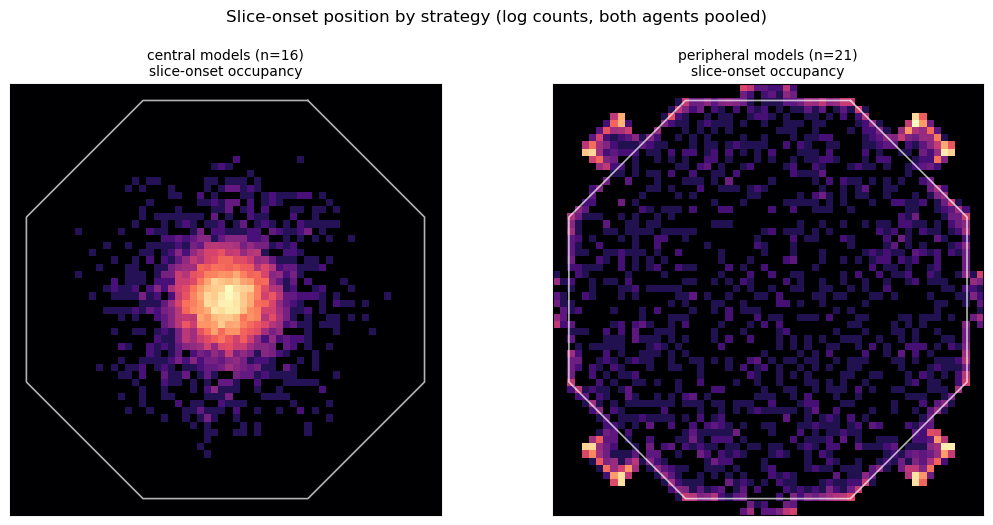

In [11]:
HIST_BINS = 60
R = mc.ARENA_RADIUS
extent = [-R, R, -R, R]
hrange = [[-R, R], [-R, R]]
slice_df['strategy'] = slice_df['model'].map(model_meta.set_index('model')['strategy'])

oct_x, oct_y = plot_octagon.calculate_coordinates(vertex=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, lab in zip(axes, ['central', 'peripheral']):
    sub = slice_df[slice_df['strategy'] == lab]
    H, _, _ = np.histogram2d(sub['x'].to_numpy(float), sub['z'].to_numpy(float),
                             bins=HIST_BINS, range=hrange)
    ax.imshow(np.log1p(H).T, origin='lower', extent=extent, cmap='magma', aspect='equal')
    ax.plot(oct_x, oct_y, color='white', lw=1.2, alpha=0.7)
    ax.set_title(f'{lab} models (n={(model_meta.strategy == lab).sum()})\nslice-onset occupancy', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Slice-onset position by strategy (log counts, both agents pooled)', y=1.0)
plt.tight_layout(); plt.show()

## Stage 3 - multivariate fingerprint & tournament shortlist

PCA of the standardised metrics shows whether centrality is the main thing separating these models, or just one of several. Then a shortlist for the tournament: the two extremes, the most typical model of each strategy (its medoid), and the best in-session scorer of each. This spans the range of strategies while including the strongest models.

PC1 explains 71%, PC2 16% of fingerprint variance
corr(PC1, slice-onset centrality) = -0.89  (|r|~1 => centrality is the main axis; ~0 => something else is)


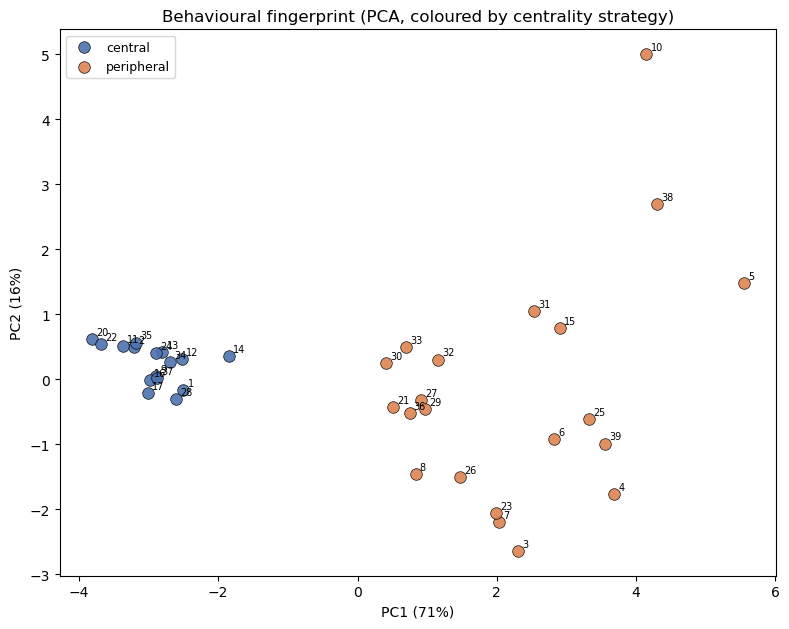

In [12]:
fingerprint, pca = mc.add_fingerprint_pca(fingerprint)
mc.report_pca(fingerprint, pca)

fig, ax = plt.subplots(figsize=(8, 6.4))
for lab in ['central', 'peripheral']:
    sub = fingerprint[fingerprint['strategy'] == lab]
    ax.scatter(sub['pc1'], sub['pc2'], s=70, color=mc.STRAT_PALETTE[lab],
               edgecolor='black', linewidth=0.5, label=lab, alpha=0.9)
for _, r in fingerprint.iterrows():
    ax.annotate(int(r['model']), (r['pc1'], r['pc2']), fontsize=7, xytext=(3, 3),
                textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('Behavioural fingerprint (PCA, coloured by centrality strategy)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

In [13]:
shortlist = mc.tournament_shortlist(fingerprint, extra_cols=('train_steps',))
print("Suggested tournament shortlist (spans the strategy axis, includes strongest in-session scorers):")
print("NB in-session score is a self-play proxy only — the tournament is the real ranking.")
shortlist.round(3)

Suggested tournament shortlist (spans the strategy axis, includes strongest in-session scorers):
NB in-session score is a self-play proxy only — the tournament is the real ranking.


,role,model,strategy,train_steps,onset_centrality,p_high,mean_score
0,most_central,22,central,4e6,0.893,0.910,0.506
1,most_peripheral,21,peripheral,4e6,-0.055,0.818,0.414
2,typical_central,2,central,4e6,0.856,0.854,0.497
3,typical_peripheral,26,peripheral,3e6,-0.036,0.693,0.442
4,best_scorer_peripheral,10,peripheral,4e6,0.382,0.784,0.473


### Final tournament shortlist

Chosen from this run's fingerprint under the score-based framing: **player score** (terminal 1.0 High / 0.4 Low / 0 lost) for performance, promptness (`pct_over_5s` = fraction of trials slower than 5 s to complete), and strategy coverage. Poorly-trained models are excluded — notably **model 5** (score-rank #34 of 37, with a slow-completion tail), which the earlier reward metric had flattered.

Eight models, **3 central / 2 intermediate / 3 peripheral**, each a healthy performer of its strategy:
- **Central (22, 20, 2):** the three best central scorers (all 0% trials over 5 s). 22 is both the most central and the #1 overall scorer.
- **Intermediate (14, 10):** the only two models in the centrality gap — 14 central-leaning, 10 peripheral-leaning. 10 carries the one notable completion tail (kept as the sole peripheral-leaning intermediate).
- **Peripheral (36, 15, 26):** best peripheral scorer + prompt (36, replacing 5), most High-seeking peripheral (15), and a typical 3e6 representative (26).

Ranks are out of the usable models (1 = highest); PC1 = strategy axis, PC2 = performance axis. Score is a self-play proxy — the tournament is the real ranking.

In [14]:
# final shortlist (role -> model), decided under the score + completion-time framing
CURATED = [
    ('most_central (top scorer)', 22), ('strong_central', 20), ('typical_central', 2),
    ('intermediate_central_leaning', 14), ('intermediate_peripheral_leaning', 10),
    ('best_peripheral', 36), ('high_Phigh_peripheral', 15), ('typical_peripheral', 26),
]
mc.curated_table(fingerprint, CURATED, extra_cols=('train_steps',))

,role,model,strategy,train_steps,centrality,cent_rk,p_high,pHigh_rk,mean_score,score_rk,pct_over_5s,resting,PC1,PC2
0,most_central (top scorer),22,central,4e6,0.89,1,0.91,1,0.506,1,0.000,0.06,-3.68,0.55
1,strong_central,20,central,4e6,0.88,6,0.87,6,0.503,2,0.000,0.05,-3.81,0.62
2,typical_central,2,central,4e6,0.86,10,0.85,8,0.497,3,0.000,0.10,-3.21,0.49
3,intermediate_central_leaning,14,central,4e6,0.58,16,0.88,3,0.490,5,0.000,0.26,-1.84,0.35
4,intermediate_peripheral_leaning,10,peripheral,4e6,0.38,17,0.78,21,0.473,8,0.067,0.63,4.15,5.00
5,best_peripheral,36,peripheral,3e6,0.00,25,0.75,23,0.455,13,0.005,0.41,0.75,-0.52
6,high_Phigh_peripheral,15,peripheral,4e6,0.03,21,0.84,11,0.453,14,0.020,0.68,2.90,0.78
7,typical_peripheral,26,peripheral,3e6,-0.04,32,0.69,27,0.442,16,0.005,0.49,1.48,-1.50


## Reading the results

- **Stage 1** places every model on one axis, its position when the trial starts. The plots show whether the models spread smoothly or fall into groups, and whether the two splits agree on which group each model is in.
- **Stage 2** separates what the strategy is from how models differ in other ways. Metrics that track the central/peripheral split (centrality, wall-visibility-at-onset) are part of the strategy. Metrics that vary within a strategy (scanning, scoring) tell similar models apart on a second dimension.
- **Stage 3** checks whether centrality is the main axis in the full metric set (PC1 correlation) and proposes a shortlist that spans the range while including the best in-session scorers.

**Caveats.** In self-play, where an agent stands at slice onset depends partly on its opponent, so centrality reflects both agents, not one model alone. The tournament (models vs *other* models) is what actually ranks competitive strength. As in prior sim runs, inference policies are near-deterministic and often split into two behaviours across models, so read the per-model bars, not just strategy means. Training length (4e6 vs 3e6, model >= 25) is the one real parameter difference; the strategy-by-training-length crosstab shows whether the shorter run pushed models toward one strategy.